In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/courseproject'
os.chdir(BASE_PATH)

print("Current dir:", os.getcwd())
print("Files:", os.listdir())

Mounted at /content/drive
Current dir: /content/drive/MyDrive/courseproject
Files: ['user_task_submissions.csv', 'README.txt', 'user_practice_submissions.csv', 'user_competences.csv', 'task_competence_mapping.csv', 'micromodules_competencies.csv', 'Screenshot_4.png']


In [ ]:
tasks = pd.read_csv("user_task_submissions.csv", sep=";")
mapping = pd.read_csv("task_competence_mapping.csv", sep=";")
user_comp = pd.read_csv("user_competences.csv", sep=";")
practice = pd.read_csv("user_practice_submissions.csv", sep=";")

In [ ]:
tasks["submission_time"] = pd.to_datetime(tasks["submission_time"], errors="coerce")
practice["submission_time"] = pd.to_datetime(practice["submission_time"], errors="coerce")

tasks_small = tasks[[
    "user_id",
    "practice_submission_id",
    "task_id",
    "submission_time"
]].copy()

mapping_small = mapping[[
    "task_id",
    "competence_id"
]].copy()

user_comp_small = user_comp[[
    "user_id",
    "competence_id",
    "probability"
]].copy()

practice_small = practice[[
    "user_id",
    "practice_submission_id",
    "kim_number",
    "submission_time"
]].copy().rename(columns={"submission_time": "practice_time"})

In [ ]:
df = (
    tasks_small
    .merge(mapping_small, on="task_id", how="left")
    .merge(user_comp_small, on=["user_id", "competence_id"], how="left")
    .merge(practice_small, on=["user_id", "practice_submission_id"], how="left")
)

In [ ]:
df["mastery_group"] = np.where(df["probability"] > 0.6, "high", "low")

In [ ]:
first_seen = (
    df.dropna(subset=["submission_time", "competence_id"])
      .groupby(["user_id", "competence_id"], as_index=False)["submission_time"]
      .min()
      .rename(columns={"submission_time": "first_competence_time"})
)

df = df.merge(first_seen, on=["user_id", "competence_id"], how="left")

df["solved_before_practice"] = np.where(
    df["first_competence_time"] < df["practice_time"],
    1,
    0
)

In [ ]:
def assign_bucket(row):
    if row["mastery_group"] == "high" and row["solved_before_practice"] == 0:
        return "high_not_solved"
    elif row["mastery_group"] == "high" and row["solved_before_practice"] == 1:
        return "high_solved"
    elif row["mastery_group"] == "low" and row["solved_before_practice"] == 1:
        return "low_solved"
    else:
        return "low_not_solved"

df["bucket"] = df.apply(assign_bucket, axis=1)

In [ ]:
practice_distribution = (
    df.groupby(["user_id", "practice_submission_id", "kim_number", "bucket"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

bucket_cols = ["high_not_solved", "high_solved", "low_solved", "low_not_solved"]

for col in bucket_cols:
    if col not in practice_distribution.columns:
        practice_distribution[col] = 0

practice_distribution["total_tasks"] = practice_distribution[bucket_cols].sum(axis=1)

for col in bucket_cols:
    practice_distribution[f"{col}_pct"] = practice_distribution[col] / practice_distribution["total_tasks"]

In [ ]:
summary_df = pd.DataFrame({
    "bucket": ["high_not_solved", "high_solved", "low_solved", "low_not_solved"],
    "actual": [
        practice_distribution["high_not_solved_pct"].mean(),
        practice_distribution["high_solved_pct"].mean(),
        practice_distribution["low_solved_pct"].mean(),
        practice_distribution["low_not_solved_pct"].mean()
    ],
    "target": [0.20, 0.10, 0.30, 0.40]
})

summary_df["diff"] = summary_df["actual"] - summary_df["target"]
summary_df

,bucket,actual,target,diff
0,high_not_solved,0.069761,0.2,-0.130239
1,high_solved,0.271862,0.1,0.171862
2,low_solved,0.249597,0.3,-0.050403
3,low_not_solved,0.408780,0.4,0.008780


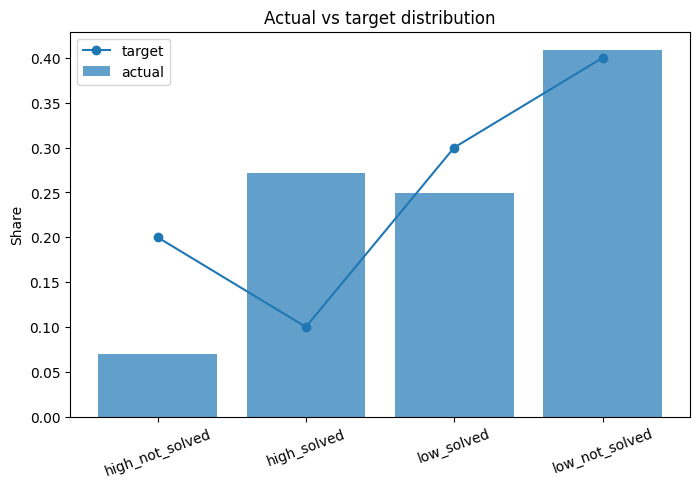

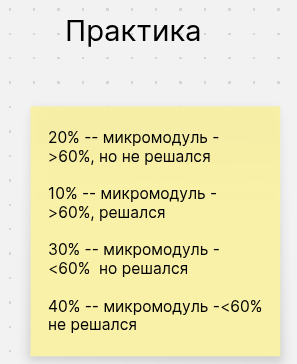

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["bucket"], summary_df["actual"], alpha=0.7, label="actual")
plt.plot(summary_df["bucket"], summary_df["target"], marker="o", label="target")
plt.title("Actual vs target distribution")
plt.ylabel("Share")
plt.legend()
plt.xticks(rotation=20)
plt.show()

from IPython.display import Image
Image('Screenshot_4.png')

In [ ]:
diagnostics = {
    "rows_in_df": len(df),
    "rows_without_competence_id": int(df["competence_id"].isna().sum()),
    "rows_without_probability": int(df["probability"].isna().sum()),
    "rows_without_practice_time": int(df["practice_time"].isna().sum()),
    "unique_users": int(df["user_id"].nunique()),
    "unique_practices": int(df["practice_submission_id"].nunique())
}

diagnostics

{'rows_in_df': 117699,
 'rows_without_competence_id': 460,
 'rows_without_probability': 835,
 'rows_without_practice_time': 0,
 'unique_users': 34,
 'unique_practices': 295}

In [ ]:
practice_distribution[[
    "user_id",
    "practice_submission_id",
    "kim_number",
    "total_tasks",
    "high_not_solved_pct",
    "high_solved_pct",
    "low_solved_pct",
    "low_not_solved_pct"
]].head(10)

bucket,user_id,practice_submission_id,kim_number,total_tasks,high_not_solved_pct,high_solved_pct,low_solved_pct,low_not_solved_pct
0,04faac8a-55ba-45e8-b22b-3defa5512390,2a455244-e03f-4d2b-a72b-1dffc62424ec,3.0,58,0.034483,0.275862,0.551724,0.137931
1,04faac8a-55ba-45e8-b22b-3defa5512390,89412f51-088d-4b42-bd8e-a33a2cac7486,1.0,30,0.166667,0.200000,0.000000,0.633333
2,04faac8a-55ba-45e8-b22b-3defa5512390,91697e10-1e2d-4e94-a7f5-0b4024bcb609,2.0,58,0.103448,0.189655,0.258621,0.448276
3,04faac8a-55ba-45e8-b22b-3defa5512390,aee4b5c4-787f-454a-be0c-003b49858f44,4.0,54,0.000000,0.203704,0.703704,0.092593
4,0e24ff0e-c58a-4a6c-b054-e80df6607b99,94669ebf-003f-44be-94c5-d25fdabcb05c,1.0,35,0.000000,0.000000,0.000000,1.000000
5,17993c65-1f0e-4f0a-b458-a7c688b99ea0,34692df5-89bf-4aae-8462-af41a1f3bafa,7.0,143,0.000000,0.377622,0.601399,0.020979
6,17993c65-1f0e-4f0a-b458-a7c688b99ea0,590cf15a-1e01-449e-92be-36d421a73fda,1.0,173,0.271676,0.000000,0.000000,0.728324
7,17993c65-1f0e-4f0a-b458-a7c688b99ea0,5a82a821-4f24-4576-9585-fd49d2692eb8,5.0,155,0.000000,0.322581,0.625806,0.051613
8,17993c65-1f0e-4f0a-b458-a7c688b99ea0,79867e7c-b6e5-41e5-9f6d-c06af043842a,8.0,125,0.000000,0.400000,0.576000,0.024000
9,17993c65-1f0e-4f0a-b458-a7c688b99ea0,7c7819e6-5362-4eed-aaf9-9438f18e734a,3.0,171,0.011696,0.274854,0.690058,0.023392


In [ ]:
kim_distribution = (
    df.groupby(["kim_number", "bucket"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

bucket_cols = ["high_not_solved", "high_solved", "low_solved", "low_not_solved"]

for col in bucket_cols:
    if col not in kim_distribution.columns:
        kim_distribution[col] = 0

kim_distribution["total_tasks"] = kim_distribution[bucket_cols].sum(axis=1)

for col in bucket_cols:
    kim_distribution[f"{col}_pct"] = kim_distribution[col] / kim_distribution["total_tasks"]

kim_distribution = kim_distribution[[
    "kim_number",
    "total_tasks",
    "high_not_solved_pct",
    "high_solved_pct",
    "low_solved_pct",
    "low_not_solved_pct"
]].sort_values("kim_number")

kim_distribution

bucket,kim_number,total_tasks,high_not_solved_pct,high_solved_pct,low_solved_pct,low_not_solved_pct
0,1.0,5450,0.511927,0.034312,0.027156,0.426606
1,2.0,3442,0.014236,0.569436,0.332655,0.083672
2,3.0,4339,0.003457,0.629869,0.332104,0.034570
3,4.0,4594,0.005007,0.566173,0.388768,0.040052
4,5.0,4065,0.000000,0.585732,0.398278,0.015990
5,6.0,3878,0.002321,0.579938,0.390665,0.027076
6,7.0,3556,0.061867,0.625703,0.288808,0.023622
7,8.0,3732,0.000000,0.602358,0.393623,0.004019
8,9.0,3543,0.000000,0.624047,0.374824,0.001129
9,10.0,2693,0.000000,0.658374,0.335685,0.005941


/tmp/ipykernel_11456/3700971507.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(y*100)}%" for y in yticks])


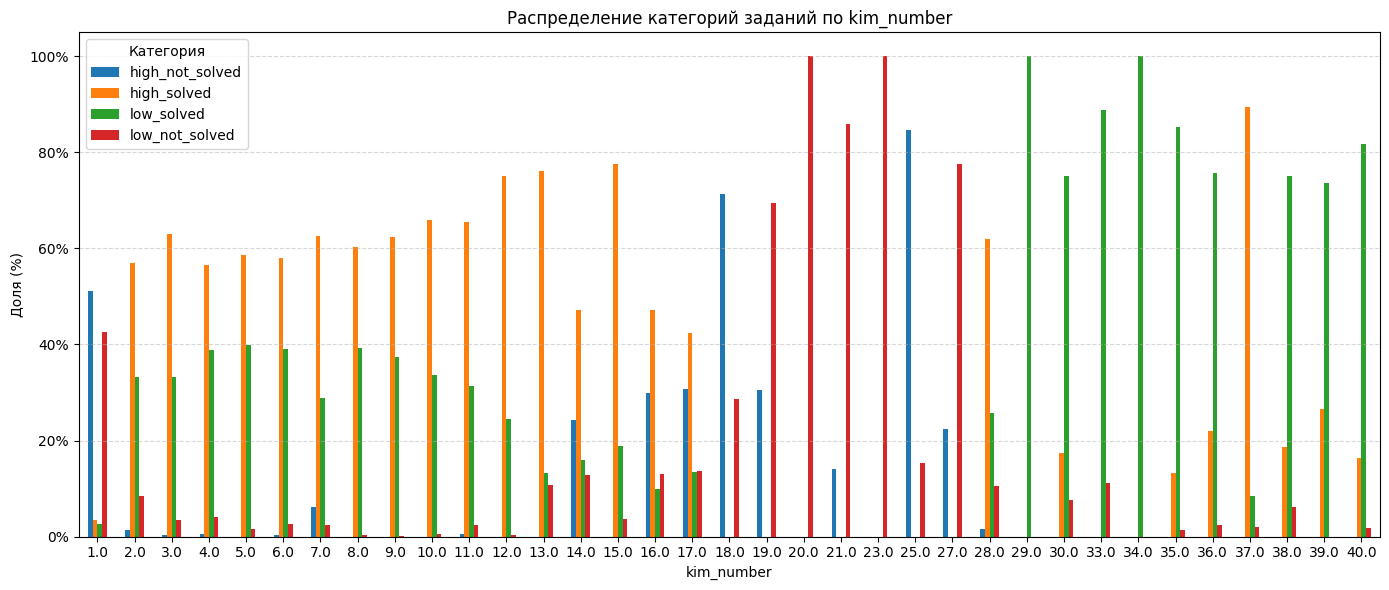

In [ ]:
ax = kim_distribution.set_index("kim_number")[[
    "high_not_solved_pct",
    "high_solved_pct",
    "low_solved_pct",
    "low_not_solved_pct"
]].plot(kind="bar", figsize=(14, 6))

plt.title("Распределение категорий заданий по kim_number")
plt.ylabel("Доля (%)")
plt.xlabel("kim_number")

yticks = ax.get_yticks()
ax.set_yticklabels([f"{int(y*100)}%" for y in yticks])

plt.legend([
    "high_not_solved",
    "high_solved",
    "low_solved",
    "low_not_solved"
], title="Категория")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
kim_deviation = kim_distribution[["kim_number"]].copy()

kim_deviation["total_abs_deviation"] = (
    (kim_distribution["high_not_solved_pct"] - 0.20).abs() +
    (kim_distribution["high_solved_pct"] - 0.10).abs() +
    (kim_distribution["low_solved_pct"] - 0.30).abs() +
    (kim_distribution["low_not_solved_pct"] - 0.40).abs()
)

kim_deviation.sort_values("total_abs_deviation", ascending=False)

bucket,kim_number,total_abs_deviation
31,37.0,1.590795
25,29.0,1.400000
28,34.0,1.400000
14,15.0,1.349669
12,13.0,1.322241
11,12.0,1.301767
22,25.0,1.291700
33,39.0,1.200000
19,20.0,1.200000
21,23.0,1.200000


Последние 3 ячейки - я сгруппировал все задачи по *kim_number* и для каждого номера посчитал долю задач наших 4 типов - *high_not_solved*, *high_solved*,*low_solved*, *low_not_solved*.

После этого я сравнил их распределение с изначальным (20/10/30/40) и посчитал суммарное отклонение для каждого номера, чтобы понять, какие *kim_number* сильнее всего отклоняются от 20/10/30/40

График, чтобы посмотреть, как распределение отличается между номерами.

Из наблюдений:

- Практически ни один *kim_number* не близок к схеме 20/10/30/40
- Категория *high_not_solved* почти отсутствует, во многих номерах её доля близка к нулю, хотя по логике должна быть около 20%
- Категория *high_solved* иногда переизбыточна, во многих номерах она достигает 60-80% вместо нужных 10%
- Некоторые номера почти полностью состоят из одной категории (например, почти весь *high_solved*(номер 37) или *low_solved*(номер 34) или *low_not_solved*(номер 20))

In [ ]:
sorted(df["kim_number"].dropna().unique()) #не знаю, почему нет некоторых номеров заданий, но видимо их нет в данных :(

[np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(11.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(17.0),
 np.float64(18.0),
 np.float64(19.0),
 np.float64(20.0),
 np.float64(21.0),
 np.float64(23.0),
 np.float64(25.0),
 np.float64(27.0),
 np.float64(28.0),
 np.float64(29.0),
 np.float64(30.0),
 np.float64(33.0),
 np.float64(34.0),
 np.float64(35.0),
 np.float64(36.0),
 np.float64(37.0),
 np.float64(38.0),
 np.float64(39.0),
 np.float64(40.0)]